In [ ]:
# Data Preprocessing & Visualization
import sys
import numpy as np
from scipy.stats import randint
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from statsmodels.tsa.seasonal import STL

# Deep-learing:
import keras
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, Conv1D, MaxPooling1D, Attention, Concatenate, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
import itertools

# **1. Data Preprocessing**

In [ ]:
df = pd.read_csv("household_power_consumption.txt", sep=";", parse_dates={'Datetime': ['Date', 'Time']},
                 dayfirst=True, low_memory=False, na_values=["?"], index_col='Datetime')

/tmp/ipython-input-955928431.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("household_power_consumption.txt", sep=";", parse_dates={'Datetime': ['Date', 'Time']},


In [ ]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [ ]:
df.shape

(2075259, 7)

In [ ]:
# Handling missing values
print(f"Missing values before: {df.isnull().sum().sum()}")

# Time-series specific imputation (Forward & Backward fill)
for column in df.columns:
    if df[column].isnull().sum() > 0:
          df[column] = df[column].ffill()
          df[column] = df[column].bfill()
print(f"Missing values after: {df.isnull().sum().sum()}")

Missing values before: 181853
Missing values after: 0


In [ ]:
# Outlier Detection and Treatment
def handle_outliers(series, window=24, threshold=3):
    """Rolling Z-score based outlier detection"""
    rolling_mean = series.rolling(window=window, min_periods=1).mean()
    rolling_std = series.rolling(window=window, min_periods=1).std()
    z_scores = np.abs((series - rolling_mean) / rolling_std)

    # Replace outliers with rolling median
    rolling_median = series.rolling(window=window, min_periods=1).median()
    return np.where(z_scores > threshold, rolling_median, series)

# Apply outlier treatment to numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
outliers_detected = 0

for col in numeric_cols:
    original = df[col].copy()
    df[col] = handle_outliers(df[col])
    outliers_detected += (original != df[col]).sum()

print(f"Outliers detected and treated: {outliers_detected}")

Outliers detected and treated: 284968


In [ ]:
def engineer_features(df, target_col='Global_active_power'):
    """Create temporal and engineered features"""
    df_temp = df.copy()

    # Temporal features
    print("Creating temporal features...")
    df_temp['hour'] = df_temp.index.hour
    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['day_of_month'] = df_temp.index.day
    df_temp['month'] = df_temp.index.month
    df_temp['quarter'] = df_temp.index.quarter
    df_temp['is_weekend'] = df_temp['day_of_week'].isin([5, 6]).astype(int)
    df_temp['is_holiday'] = 0  # Placeholder

    # Cyclical encoding
    print("Creating cyclical features...")
    df_temp['hour_sin'] = np.sin(2 * np.pi * df_temp['hour'] / 24)
    df_temp['hour_cos'] = np.cos(2 * np.pi * df_temp['hour'] / 24)
    df_temp['day_sin'] = np.sin(2 * np.pi * df_temp['day_of_week'] / 7)
    df_temp['day_cos'] = np.cos(2 * np.pi * df_temp['day_of_week'] / 7)
    df_temp['month_sin'] = np.sin(2 * np.pi * df_temp['month'] / 12)
    df_temp['month_cos'] = np.cos(2 * np.pi * df_temp['month'] / 12)

    # Lag features
    print("Creating lag features...")
    lag_periods = [1, 2, 3, 4, 24, 48, 72, 168]  # 1h to 1 week
    for lag in lag_periods:
        df_temp[f'{target_col}_lag_{lag}'] = df_temp[target_col].shift(lag)

    # Rolling statistics
    print("Creating rolling statistics...")
    windows = [3, 6, 12, 24, 168]  # 3h to 1 week
    for window in windows:
        df_temp[f'{target_col}_rolling_{window}_mean'] = df_temp[target_col].rolling(window=window).mean()
        df_temp[f'{target_col}_rolling_{window}_std'] = df_temp[target_col].rolling(window=window).std()
        df_temp[f'{target_col}_rolling_{window}_min'] = df_temp[target_col].rolling(window=window).min()
        df_temp[f'{target_col}_rolling_{window}_max'] = df_temp[target_col].rolling(window=window).max()

    # Differencing
    print("Creating differenced features...")
    df_temp[f'{target_col}_diff_1'] = df_temp[target_col].diff(1)
    df_temp[f'{target_col}_diff_24'] = df_temp[target_col].diff(24)

    # Interaction features
    print("Creating interaction features...")
    df_temp['power_voltage_ratio'] = df_temp['Global_active_power'] / df_temp['Voltage']
    df_temp['power_intensity_ratio'] = df_temp['Global_active_power'] / df_temp['Global_intensity']

    print(f"Total features after engineering: {df_temp.shape[1]}")
    print(f"New features created: {df_temp.shape[1] - df.shape[1]}")

    return df_temp


df_processed = engineer_features(df)

Creating temporal features...
Creating cyclical features...
Creating lag features...
Creating rolling statistics...
Creating differenced features...
Creating interaction features...
Total features after engineering: 52
New features created: 45


In [ ]:
# Feature Scaling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)

print("DataFrame scaled using MinMaxScaler.")
display(df_scaled.head())

DataFrame scaled using MinMaxScaler.


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,0.374796,0.300719,0.370189,0.377593,0.0,0.0125,0.548387
2006-12-16 17:25:00,0.478363,0.313669,0.330724,0.473029,0.0,0.0125,0.516129
2006-12-16 17:26:00,0.479631,0.358273,0.319635,0.473029,0.0,0.0250,0.548387
2006-12-16 17:27:00,0.480898,0.361151,0.334312,0.473029,0.0,0.0125,0.548387
2006-12-16 17:28:00,0.325005,0.379856,0.397586,0.323651,0.0,0.0125,0.548387


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

def select_features(df, target_col='Global_active_power', k=50):
    """Select most important features"""

    df_temp = df.copy()

    # Drop rows with NaN created by lag/rolling features
    initial_rows = len(df_temp)
    df_temp.dropna(inplace=True)
    print(f"Dropped {initial_rows - len(df_temp)} rows with NaN values")

    # Prepare for feature selection
    X = df_temp.drop(columns=[target_col])
    y = df_temp[target_col]

    # Select top features using mutual information
    k = min(k, X.shape[1])  # Ensure k doesn't exceed available features
    selector = SelectKBest(score_func=f_regression, k=k)
    X_selected = selector.fit_transform(X, y)

    # Get selected feature names
    selected_mask = selector.get_support()
    selected_features = X.columns[selected_mask]

    # Keep only selected features + target
    df_selected = df_temp[selected_features.tolist() + [target_col]]

    print(f"Features after selection: {df_selected.shape[1]}")
    print("Top 10 selected features:")
    for i, feature in enumerate(selected_features[:10]):
        print(f"  {i+1}. {feature}")

    return df_selected, selected_features

df_processed, selected_features = select_features(df_processed, k=50)

Dropped 168 rows with NaN values
Features after selection: 51
Top 10 selected features:
  1. Global_reactive_power
  2. Voltage
  3. Global_intensity
  4. Sub_metering_1
  5. Sub_metering_2
  6. Sub_metering_3
  7. hour
  8. day_of_week
  9. day_of_month
  10. month


In [ ]:
# Data Splitting (For time series: train on older data, test on newer data)
split_idx = int(len(df) * 0.8)
train_data = df.iloc[:split_idx]
test_data = df.iloc[split_idx:]

print(f"Training data: {train_data.shape} ({train_data.index.min()} to {train_data.index.max()})")
print(f"Test data: {test_data.shape} ({test_data.index.min()} to {test_data.index.max()})")

Training data: (1660207, 7) (2006-12-16 17:24:00 to 2010-02-11 15:30:00)
Test data: (415052, 7) (2010-02-11 15:31:00 to 2010-11-26 21:02:00)


# **2. Data visualization**

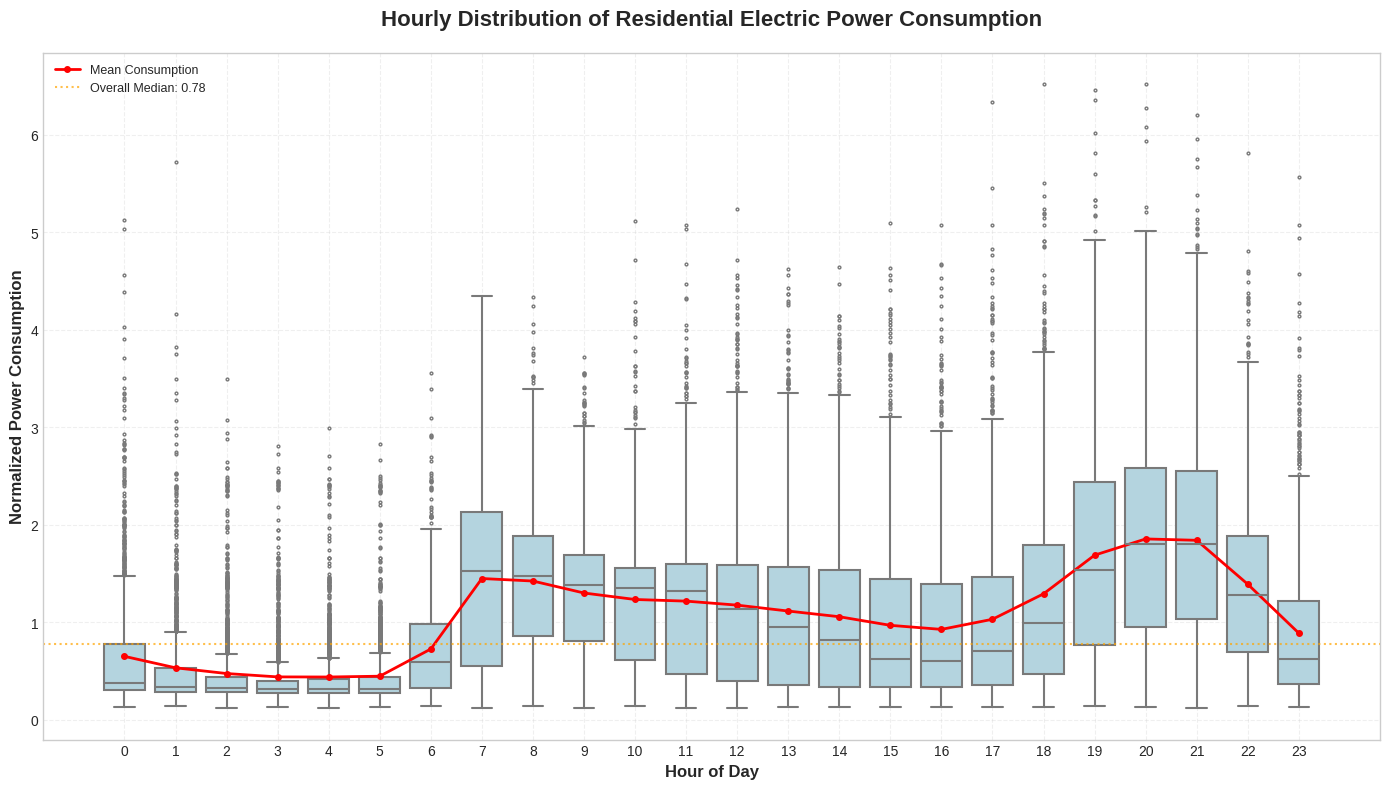

Dataset spans: 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Total hours: 34589
Overall mean consumption: 1.065


In [ ]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Hourly boxplot
# Resample data to hourly frequency
hourly_df = df.resample('h').mean()

plt.figure(figsize=(14, 8))

# Create the boxplot with additional parameters for better visualization
box_plot = sns.boxplot(
    x=hourly_df.index.hour,
    y=hourly_df["Global_active_power"],
    fliersize=2,           # Smaller outlier dots
    linewidth=1.5,         # Thicker box lines
    width=0.8,            # Slightly wider boxes
    showfliers=True,       # Show outliers but make them subtle
    color='lightblue'      # Base color
)

# Customize the plot
plt.title("Hourly Distribution of Residential Electric Power Consumption",
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hour of Day", fontsize=12, fontweight='bold')
plt.ylabel("Normalized Power Consumption", fontsize=12, fontweight='bold')

# Improve x-axis labels
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Add mean line overlay for additional insight
means = hourly_df.groupby(hourly_df.index.hour)["Global_active_power"].mean()
hours = np.arange(24)
plt.plot(hours, means, 'r-', linewidth=2, marker='o', markersize=4,
         label='Mean Consumption')

# Add legend
plt.legend(loc='upper left', fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Add some statistical annotations if desired
median_val = hourly_df["Global_active_power"].median()
plt.axhline(y=median_val, color='orange', linestyle=':', alpha=0.7,
            label=f'Overall Median: {median_val:.2f}')

plt.legend(loc='upper left', fontsize=9)

plt.show()

# Summary statistics
print(f"Dataset spans: {hourly_df.index.min()} to {hourly_df.index.max()}")
print(f"Total hours: {len(hourly_df)}")
print(f"Overall mean consumption: {hourly_df['Global_active_power'].mean():.3f}")

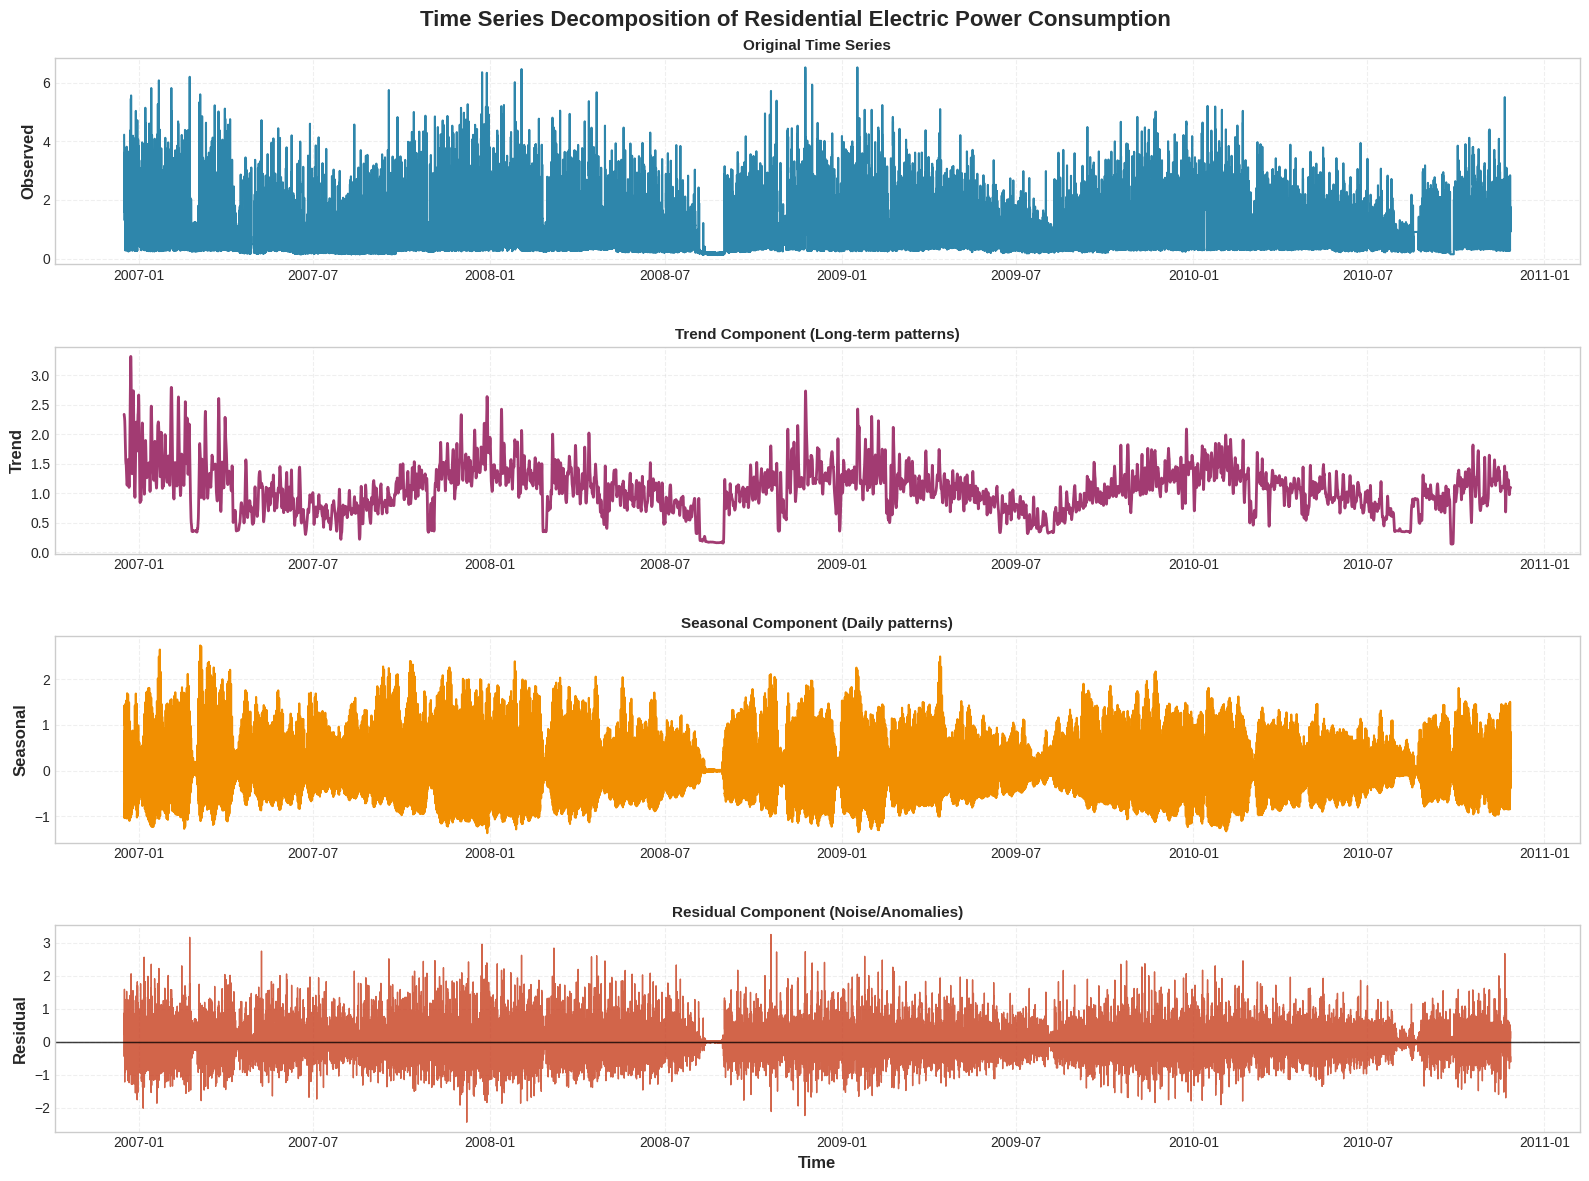

Decomposition Analysis:
Observed range: 0.118 to 6.520
Trend range: 0.141 to 3.317
Seasonal amplitude: ±2.734
Residual statistics:
  Mean: 0.000106
  Standard deviation: 0.476588
  Non-zero residuals: 34589/34589


In [ ]:
# Decomposition plot
# Set style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Perform decomposition
stl = STL(hourly_df["Global_active_power"], period=24)
decomp = stl.fit()

# Create custom subplots with better layout
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Time Series Decomposition of Residential Electric Power Consumption',
             fontsize=16, fontweight='bold', y=0.98)

# Original time series
axes[0].plot(decomp.observed, linewidth=1.5, color='#2E86AB')
axes[0].set_ylabel('Observed', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_title('Original Time Series', fontsize=11, fontweight='bold')

# Trend component
axes[1].plot(decomp.trend, linewidth=2, color='#A23B72')
axes[1].set_ylabel('Trend', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_title('Trend Component (Long-term patterns)', fontsize=11, fontweight='bold')

# Seasonal component
axes[2].plot(decomp.seasonal, linewidth=1.5, color='#F18F01')
axes[2].set_ylabel('Seasonal', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_title('Seasonal Component (Daily patterns)', fontsize=11, fontweight='bold')

# Residual component
axes[3].plot(decomp.resid, linewidth=1, color='#C73E1D', alpha=0.8)
axes[3].set_ylabel('Residual', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3, linestyle='--')
axes[3].set_title('Residual Component (Noise/Anomalies)', fontsize=11, fontweight='bold')
axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add zero reference line to residuals
axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Adjust layout and spacing
plt.tight_layout()
plt.subplots_adjust(top=0.94, hspace=0.4)

plt.show()

# Additional insights
print("Decomposition Analysis:")
print(f"Observed range: {decomp.observed.min():.3f} to {decomp.observed.max():.3f}")
print(f"Trend range: {decomp.trend.min():.3f} to {decomp.trend.max():.3f}")
print(f"Seasonal amplitude: ±{decomp.seasonal.abs().max():.3f}")
print(f"Residual statistics:")
print(f"  Mean: {decomp.resid.mean():.6f}")
print(f"  Standard deviation: {decomp.resid.std():.6f}")
print(f"  Non-zero residuals: {(decomp.resid != 0).sum()}/{len(decomp.resid)}")

# **3. Deep Learning**

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
features = ["Global_active_power", "Voltage", "Global_reactive_power"]

In [ ]:
# Sliding window
def create_sliding_window(data, input_steps=60, output_steps=10):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i : i + input_steps])
        y.append(data[i + input_steps : i + input_steps + output_steps, 0])
    return np.array(X), np.array(y)

input_steps, output_steps = 60, 10
X, y = create_sliding_window(hourly_df[features].values, input_steps, output_steps)

In [ ]:
def build_cnn_lstm_attention(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(10, kernel_size=2, activation="tanh", padding="same")(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(25, return_sequences=True)(x)
    x = Dense(25, activation="tanh")(x)
    attention_out = Attention()([x, x])
    x = GlobalAveragePooling1D()(attention_out)
    outputs = Dense(output_steps, activation="linear")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

In [ ]:
def build_seq2seq_attention(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(10, kernel_size=2, activation="tanh", padding="same")(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(30, return_sequences=True)(x)
    attention_out = Attention()([x, x])
    x = GlobalAveragePooling1D()(attention_out)
    outputs = Dense(output_steps, activation="linear")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

In [ ]:
# TimeSeries cross-validation
tscv = TimeSeriesSplit(n_splits=10)

cnn_lstm_metrics = {"rmse": [], "mae": [], "mse": []}
seq2seq_metrics = {"rmse": [], "mae": [], "mse": []}

epochs = 5
batch_size = 32

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # CNN-LSTM-Attention
    cnn_lstm_model = build_cnn_lstm_attention(X_train.shape[1:])
    cnn_lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    cnn_lstm_preds = cnn_lstm_model.predict(X_test)

    # Seq2Seq-Attention
    seq2seq_model = build_seq2seq_attention(X_train.shape[1:])
    seq2seq_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    seq2seq_preds = seq2seq_model.predict(X_test)

    # Calculate metrics for CNN-LSTM
    cnn_lstm_metrics["mse"].append(mean_squared_error(y_test.flatten(), cnn_lstm_preds.flatten()))
    cnn_lstm_metrics["rmse"].append(np.sqrt(cnn_lstm_metrics["mse"][-1]))
    cnn_lstm_metrics["mae"].append(mean_absolute_error(y_test.flatten(), cnn_lstm_preds.flatten()))

    # Calculate metrics for Seq2Seq
    seq2seq_metrics["mse"].append(mean_squared_error(y_test.flatten(), seq2seq_preds.flatten()))
    seq2seq_metrics["rmse"].append(np.sqrt(seq2seq_metrics["mse"][-1]))
    seq2seq_metrics["mae"].append(mean_absolute_error(y_test.flatten(), seq2seq_preds.flatten()))

# Average metrics across folds
cnn_avg_metrics = {k: np.mean(v) for k, v in cnn_lstm_metrics.items()}
seq2seq_avg_metrics = {k: np.mean(v) for k, v in seq2seq_metrics.items()}

# Display Errors
print("\nFinal Error Comparison Between Models:")
print("CNN-LSTM Errors:")
print(f"  RMSE: {cnn_avg_metrics['rmse']:.4f}")
print(f"  MAE: {cnn_avg_metrics['mae']:.4f}")
print(f"  MSE: {cnn_avg_metrics['mse']:.4f}")
print("\nSeq2Seq Errors:")
print(f"  RMSE: {seq2seq_avg_metrics['rmse']:.4f}")
print(f"  MAE: {seq2seq_avg_metrics['mae']:.4f}")
print(f"  MSE: {seq2seq_avg_metrics['mse']:.4f}")

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Final Error Comparison Between Models:
CNN-LSTM Errors:
  RMSE: 0.8584
  MAE: 0.7134
  MSE: 0.7507

Seq2Seq Errors:
  RMSE: 0.8587
  MAE: 0.7117
  MSE: 0.7511


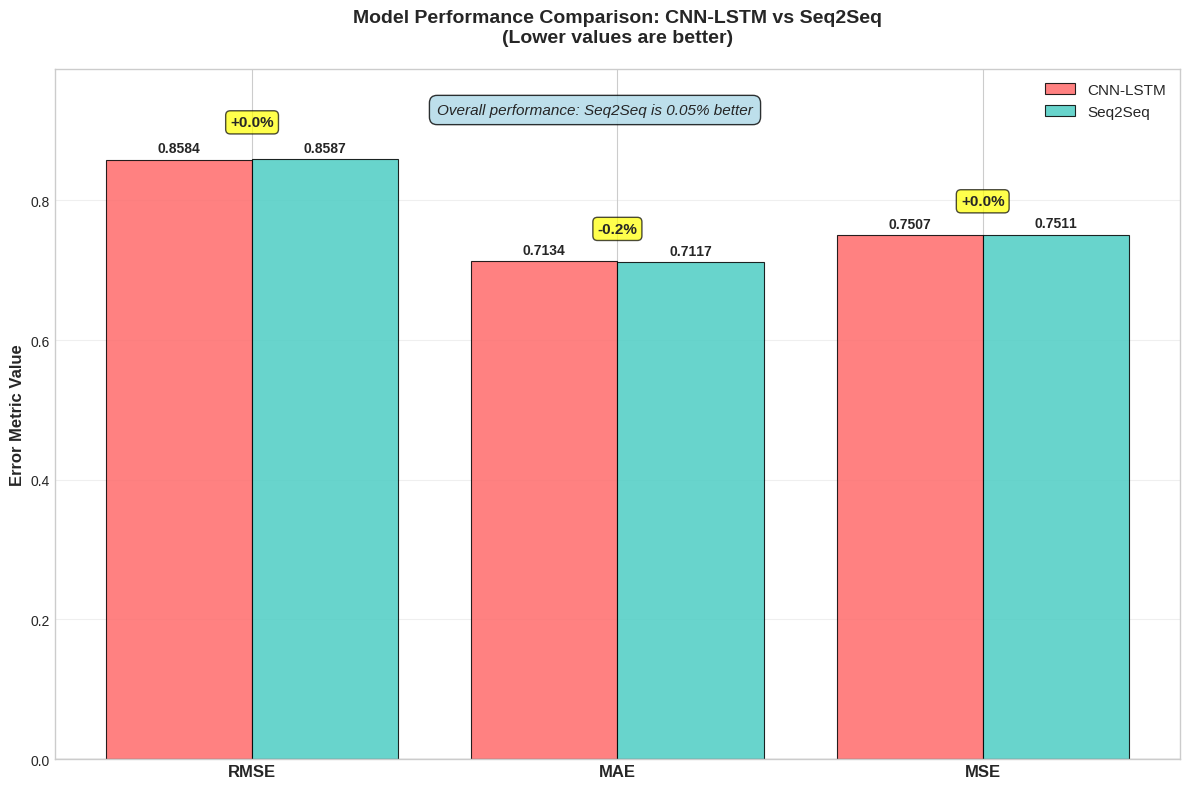

MODEL PERFORMANCE COMPARISON
Metric   CNN-LSTM     Seq2Seq      Difference   Better Model
------------------------------------------------------------
RMSE     0.858443     0.858703      +0.000261     CNN-LSTM
MAE      0.713429     0.711666      -0.001762      Seq2Seq
MSE      0.750750     0.751062      +0.000312     CNN-LSTM
------------------------------------------------------------
TOTAL    2.322621     2.321431      -0.001190      Seq2Seq


In [ ]:
# Set style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl", 2)

# Prepare data
metrics = ["RMSE", "MAE", "MSE"]
cnn_values = [cnn_avg_metrics[m.lower()] for m in metrics]
seq_values = [seq2seq_avg_metrics[m.lower()] for m in metrics]

# Calculate percentage differences for annotations
percent_diffs = [(seq - cnn) / cnn * 100 for cnn, seq in zip(cnn_values, seq_values)]

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(12, 8))

# Bar positions and width
x = np.arange(len(metrics))
width = 0.4

# Create bars with enhanced styling
bars1 = ax.bar(x - width/2, cnn_values, width,
               label='CNN-LSTM',
               alpha=0.85,
               edgecolor='black',
               linewidth=0.8,
               color='#FF6B6B')

bars2 = ax.bar(x + width/2, seq_values, width,
               label='Seq2Seq',
               alpha=0.85,
               edgecolor='black',
               linewidth=0.8,
               color='#4ECDC4')

# Add value labels on top of bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

# Add percentage difference annotations
for i, diff in enumerate(percent_diffs):
    ax.text(i, max(cnn_values[i], seq_values[i]) * 1.05,
            f"{diff:+.1f}%",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# Customize axes and labels
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylabel("Error Metric Value", fontsize=12, fontweight='bold')
ax.set_title("Model Performance Comparison: CNN-LSTM vs Seq2Seq\n(Lower values are better)",
             fontsize=14, fontweight='bold', pad=20)

# Add legend with better positioning
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Add horizontal line at zero for reference
ax.axhline(y=0, color='black', linewidth=0.8)

# Adjust y-axis to accommodate annotations
ax.set_ylim(0, max(max(cnn_values), max(seq_values)) * 1.15)

# Add some statistical summary
best_model = "CNN-LSTM" if sum(cnn_values) < sum(seq_values) else "Seq2Seq"
total_diff = (sum(seq_values) - sum(cnn_values)) / sum(cnn_values) * 100

fig.text(0.5, 0.85,
         f"Overall performance: {best_model} is {abs(total_diff):.2f}% better",
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed comparison
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Metric':<8} {'CNN-LSTM':<12} {'Seq2Seq':<12} {'Difference':<12} {'Better Model':<12}")
print("-"*60)

for i, metric in enumerate(metrics):
    better = "CNN-LSTM" if cnn_values[i] < seq_values[i] else "Seq2Seq"
    diff = seq_values[i] - cnn_values[i]
    print(f"{metric:<8} {cnn_values[i]:<12.6f} {seq_values[i]:<12.6f} {diff:>+10.6f} {better:>12}")

print("-"*60)
print(f"{'TOTAL':<8} {sum(cnn_values):<12.6f} {sum(seq_values):<12.6f} {sum(seq_values)-sum(cnn_values):>+10.6f} {best_model:>12}")
print("="*60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


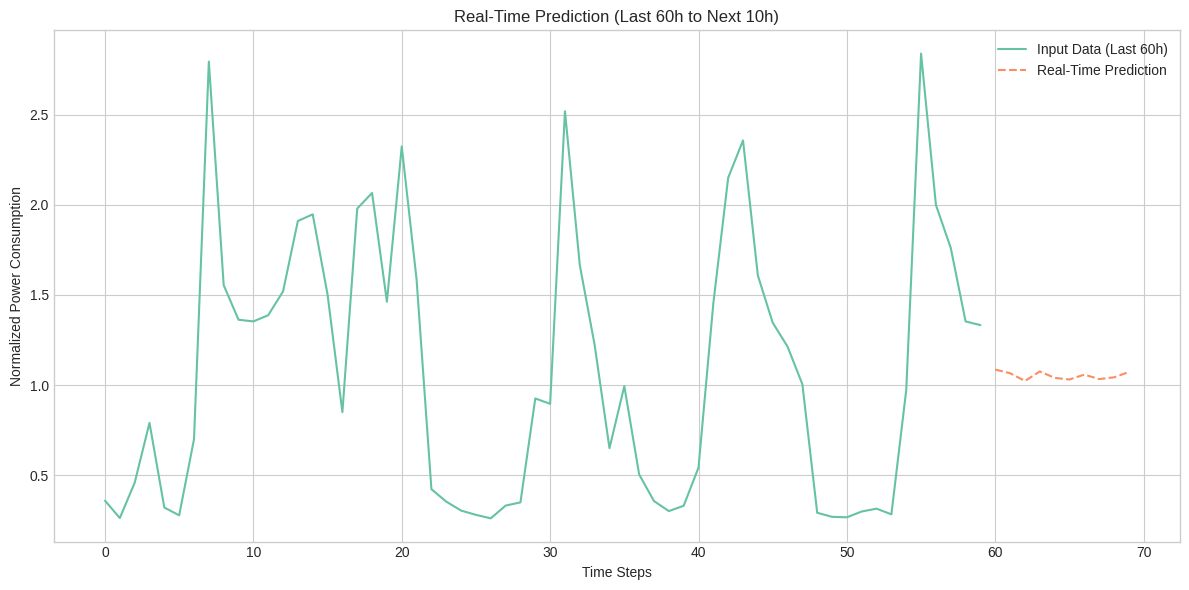

In [ ]:
# Predict on the last input window
real_time_preds = seq2seq_model.predict(X[-1].reshape(1, *X.shape[1:]))[0]

plt.figure(figsize=(12, 6))
plt.plot(range(input_steps), X[-1, :, 0], label="Input Data (Last 60h)")
plt.plot(range(input_steps, input_steps + output_steps), real_time_preds, linestyle="--", label="Real-Time Prediction")
plt.title("Real-Time Prediction (Last 60h to Next 10h)")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Power Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()